In [43]:
import datetime
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import sqlite3
database = "crypto_historical_data.db"

In [44]:
def fetch_fred_macro_data(start_date="2006-01-01", end_date=None):
    """Fetches macro data series from FRED without needing an API key.

    Series:
    - DTWEXBGS: US Dollar Index (Nominal Broad Dollar Index)
    - DGS10: 10-Year Treasury Constant Maturity Rate
    - WALCL: Federal Reserve Total Assets (Fed Balance Sheet)
    - T10Y2Y: 10-Year Treasury Constant Maturity Minus 2-Year Constant Maturity
    """
    if end_date is None:
        end_date = datetime.datetime.now().strftime("%Y-%m-%d")

    series_mapping = {
        "DTWEXBGS": "dxy",
        "DGS10": "us_10y_yield",
        "WALCL": "fed_balance_sheet",
        "T10Y2Y": "yield_curve_slope",
    }

    tickers = list(series_mapping.keys())

    try:
        # Pull data directly from FRED
        df_raw = web.DataReader(tickers, "fred", start_date, end_date)
        df = df_raw.rename(columns=series_mapping)
    except Exception as e:
        print(f"Error fetching data from FRED: {e}")
        return pd.DataFrame()

    # Create daily calendar grid to handle weekend/holiday gaps & low-frequency metrics
    full_idx = pd.date_range(start=start_date, end=end_date, freq="D")
    df = df.reindex(full_idx)

    # Forward-fill macro data (Fed Balance sheet is weekly, markets close on weekends)
    df = df.ffill().bfill()

    return df


def generate_macro_ml_features(df):
    """Generates rate-of-change, momentum, and regime features for ML training."""
    features = pd.DataFrame(index=df.index)

    # 1. Dollar Index (DXY) Momentum (14-day and 30-day % changes)
    features["dxy_roc_14d"] = df["dxy"].pct_change(14)
    features["dxy_roc_30d"] = df["dxy"].pct_change(30)

    # 2. Yield Curve slope momentum & Z-score (Inversion indicator)
    features["yield_curve_slope"] = df["yield_curve_slope"]
    rolling_mean = df["yield_curve_slope"].rolling(90).mean()
    rolling_std = df["yield_curve_slope"].rolling(90).std()
    features["yield_curve_zscore_90d"] = (
        df["yield_curve_slope"] - rolling_mean
    ) / rolling_std

    # 3. Fed Balance Sheet Velocity (Global Liquidity Proxy)
    # WALCL is reported in millions, calculate 30-day % expansion/contraction
    features["fed_bs_expansion_30d"] = df["fed_balance_sheet"].pct_change(30)

    # 4. Macro Risk-On/Off Compound Score
    # Dollar strength + rising yields = liquidity contraction (Risk-Off)
    features["liquidity_stress_index"] = (
        features["dxy_roc_14d"] + df["us_10y_yield"].pct_change(14)
    )

    return features.dropna()

In [45]:
df = fetch_fred_macro_data(start_date="2006-01-01", end_date=None)

In [46]:
features = generate_macro_ml_features(df)

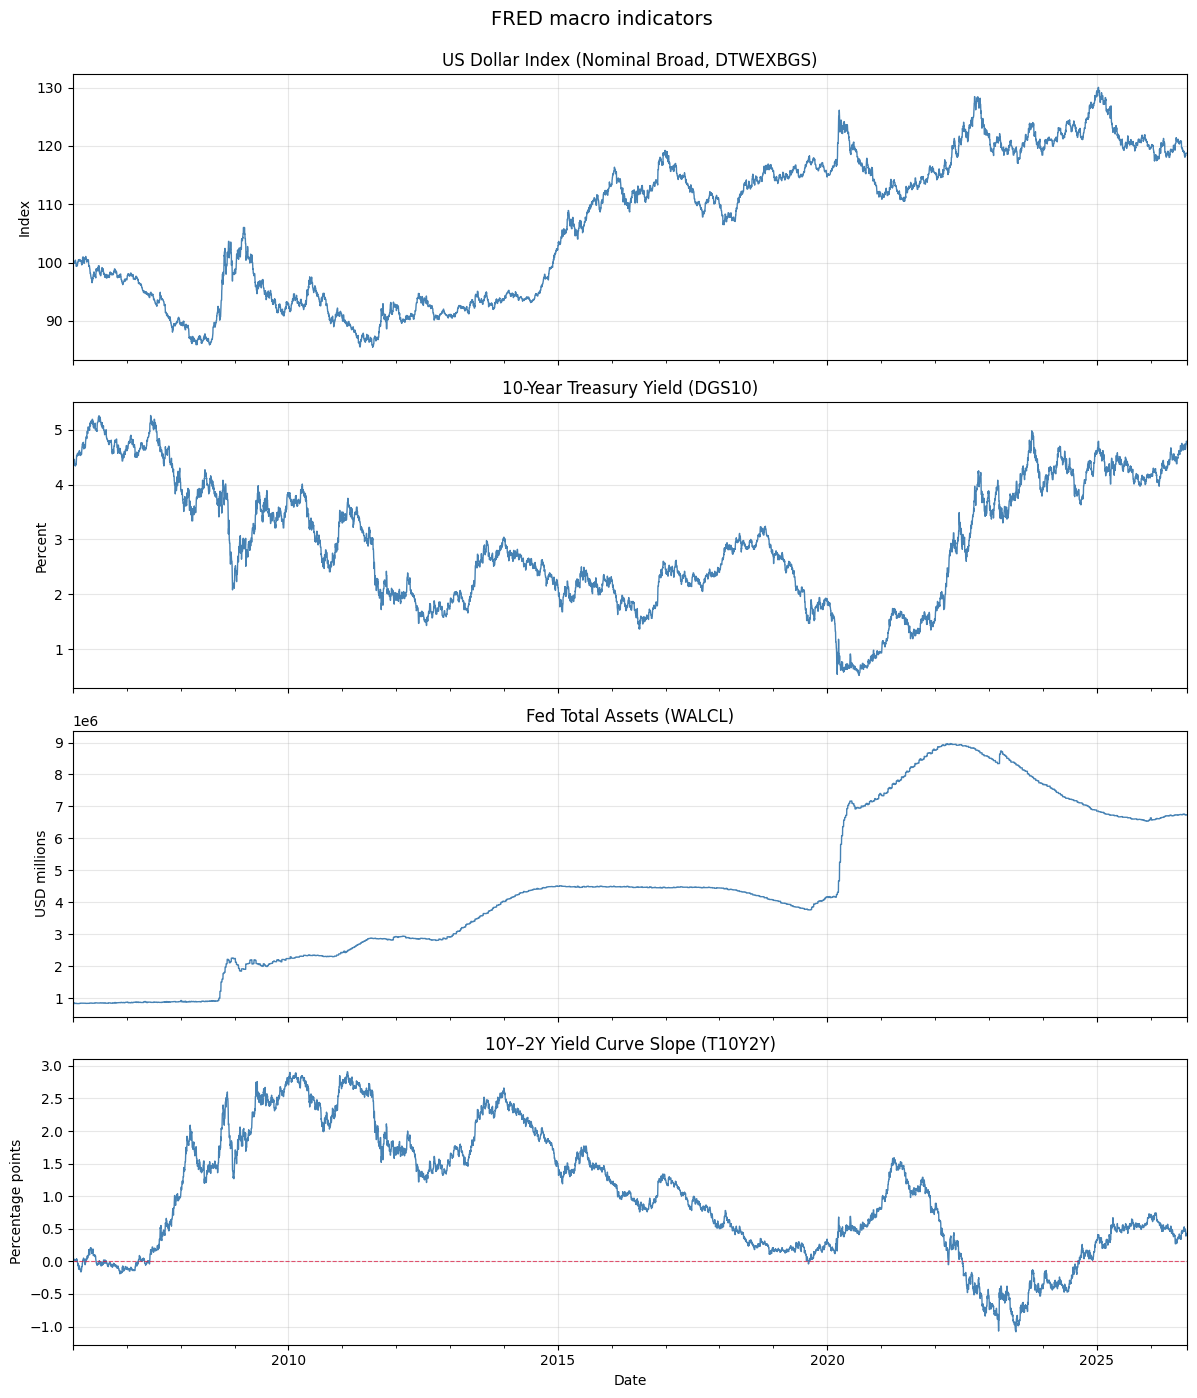

In [47]:
INDICATOR_META = {
    "dxy": {
        "title": "US Dollar Index (Nominal Broad, DTWEXBGS)",
        "ylabel": "Index",
    },
    "us_10y_yield": {
        "title": "10-Year Treasury Yield (DGS10)",
        "ylabel": "Percent",
    },
    "fed_balance_sheet": {
        "title": "Fed Total Assets (WALCL)",
        "ylabel": "USD millions",
    },
    "yield_curve_slope": {
        "title": "10Y–2Y Yield Curve Slope (T10Y2Y)",
        "ylabel": "Percentage points",
    },
}

fig, axes = plt.subplots(len(INDICATOR_META), 1, figsize=(12, 14), sharex=True)
fig.suptitle("FRED macro indicators", fontsize=14, y=0.995)

for ax, (col, meta) in zip(axes, INDICATOR_META.items()):
    df[col].plot(ax=ax, color="steelblue", linewidth=1.0)
    ax.set_title(meta["title"])
    ax.set_ylabel(meta["ylabel"])
    ax.grid(True, alpha=0.3)
    if col == "yield_curve_slope":
        ax.axhline(0, color="crimson", linewidth=0.8, linestyle="--", alpha=0.7)

axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

In [48]:
def load_crypto_data():
    with sqlite3.connect(database) as conn:
        btc = pd.read_sql("SELECT time_close, close, high, low FROM btc_price", conn)
    return btc

btc_df = load_crypto_data()
btc_df.head()

,time_close,close,high,low
0,2010-07-17T00:00:00+00:00,0.04951,0.04951,0.04951
1,2010-07-19T00:00:00+00:00,0.08080,0.09307,0.07723
2,2010-07-20T00:00:00+00:00,0.07474,0.07474,0.07426
3,2010-07-21T00:00:00+00:00,0.07921,0.07921,0.07171
4,2010-07-22T00:00:00+00:00,0.05248,0.05941,0.05050


In [49]:
# FRED uses a naive daily DatetimeIndex. BTC `time_close` mixes ISO-8601 with
# timezone (`2010-07-17T00:00:00+00:00`) and naive `YYYY-MM-DD HH:MM:SS`.
macro = df.copy()
macro.index = pd.to_datetime(macro.index, utc=False).tz_localize(None).normalize()
macro.index.name = "date"

btc = btc_df.copy()
btc["date"] = (
    pd.to_datetime(btc["time_close"], utc=True, format="mixed")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
    .dt.normalize()
)
btc = (
    btc.rename(columns={"close": "btc_close"})
    .groupby("date", as_index=True)[["btc_close"]]
    .last()
    .sort_index()
)

merged = macro.join(btc, how="inner")
print(f"macro rows: {len(macro):,} | btc rows: {len(btc):,} | merged: {len(merged):,}")
print(f"merged range: {merged.index.min().date()} → {merged.index.max().date()}")
merged.head()

macro rows: 7,554 | btc rows: 5,862 | merged: 5,862
merged range: 2010-07-17 → 2026-09-06


,dxy,us_10y_yield,fed_balance_sheet,yield_curve_slope,btc_close
date,,,,,
2010-07-17,94.5061,2.96,2340717.0,2.35,0.04951
2010-07-19,94.6020,2.99,2340717.0,2.38,0.08080
2010-07-20,94.5420,2.98,2340717.0,2.37,0.07474
2010-07-21,94.4496,2.90,2332322.0,2.32,0.07921
2010-07-22,94.1135,2.96,2332322.0,2.36,0.05248


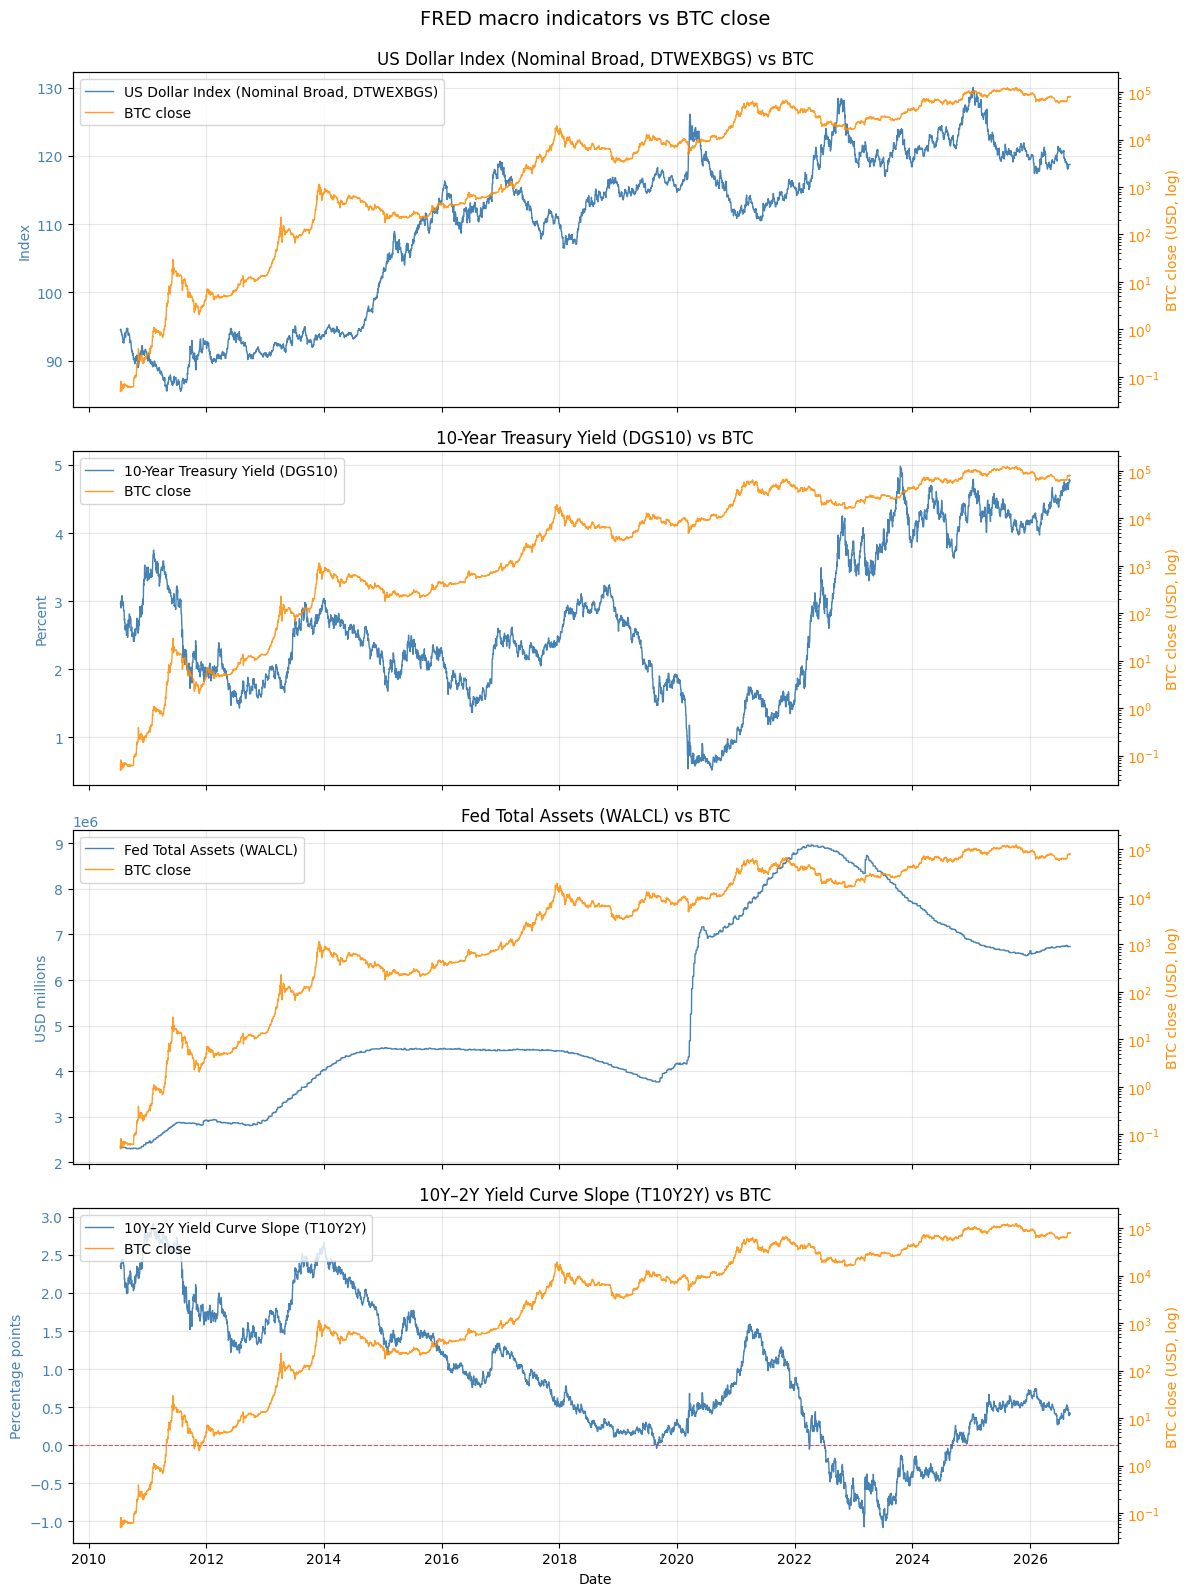

In [8]:
fig, axes = plt.subplots(len(INDICATOR_META), 1, figsize=(12, 16), sharex=True)
fig.suptitle("FRED macro indicators vs BTC close", fontsize=14, y=0.995)

for ax, (col, meta) in zip(axes, INDICATOR_META.items()):
    ax_btc = ax.twinx()
    (line_macro,) = ax.plot(
        merged.index, merged[col], color="steelblue", linewidth=1.0, label=meta["title"]
    )
    (line_btc,) = ax_btc.plot(
        merged.index,
        merged["btc_close"],
        color="darkorange",
        linewidth=1.0,
        alpha=0.85,
        label="BTC close",
    )
    ax.set_title(meta["title"] + " vs BTC")
    ax.set_ylabel(meta["ylabel"], color="steelblue")
    ax_btc.set_ylabel("BTC close (USD, log)", color="darkorange")
    ax_btc.set_yscale("log")
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax_btc.tick_params(axis="y", labelcolor="darkorange")
    ax.grid(True, alpha=0.3)
    if col == "yield_curve_slope":
        ax.axhline(0, color="crimson", linewidth=0.8, linestyle="--", alpha=0.7)
    ax.legend([line_macro, line_btc], [meta["title"], "BTC close"], loc="upper left")

axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

In [69]:
import altair as alt

indicator_meta = {
    "dxy": {
        "title": "US Dollar Index (Nominal Broad, DTWEXBGS)",
        "ylabel": "Index",
    },
    "us_10y_yield": {
        "title": "10-Year Treasury Yield (DGS10)",
        "ylabel": "Percent",
    },
    "fed_balance_sheet": {
        "title": "Fed Total Assets (WALCL)",
        "ylabel": "USD millions",
    },
    "yield_curve_slope": {
        "title": "10Y–2Y Yield Curve Slope (T10Y2Y)",
        "ylabel": "Percentage points",
    },
}



def create_indicator_chart(df, col, meta):
    """Generates an interactive dual-axis Altair chart for a macro indicator vs BTC.

    Designed for native rendering in Streamlit via st.altair_chart().
    """
    # Ensure date is a column with proper datetime dtype
    data = df.copy()
    if isinstance(data.index, pd.DatetimeIndex) or data.index.name == "date":
        data = data.reset_index()

    # Normalize date column name
    date_col = "index" if "index" in data.columns else "date"
    data[date_col] = pd.to_datetime(data[date_col])

    # 1. Base x-axis configuration
    base = alt.Chart(data).encode(
        x=alt.X(
            f"{date_col}:T",
            title="Date",
            axis=alt.Axis(format="%Y-%m", grid=True, gridOpacity=0.1),
        )
    )

    # 2. Primary Y-Axis: Macro Indicator (Left Axis)
    macro_line = base.mark_line(color="steelblue", strokeWidth=1.5).encode(
        y=alt.Y(
            f"{col}:Q",
            title=meta["ylabel"],
            scale=alt.Scale(zero=False),
            axis=alt.Axis(
                titleColor="steelblue",
                labelColor="steelblue",
                grid=True,
                gridOpacity=0.15,
            ),
        ),
        tooltip=[
            alt.Tooltip(f"{date_col}:T", title="Date", format="%Y-%m-%d"),
            alt.Tooltip(f"{col}:Q", title=meta["title"], format=".2f"),
        ],
    )

    # 3. Secondary Y-Axis: BTC Close (Right Axis, Log Scale)
    btc_line = base.mark_line(
        color="darkorange", strokeWidth=1.5, opacity=0.85
    ).encode(
        y=alt.Y(
            "btc_close:Q",
            title="BTC Close (USD, log)",
            scale=alt.Scale(type="log"),
            axis=alt.Axis(
                titleColor="darkorange", labelColor="darkorange", orient="right"
            ),
        ),
        tooltip=[
            alt.Tooltip(f"{date_col}:T", title="Date", format="%Y-%m-%d"),
            alt.Tooltip("btc_close:Q", title="BTC Close", format="$,.2f"),
        ],
    )

    # 4. Optional reference line for yield curve inversion
    if col == "yield_curve_slope":
        ref_data = pd.DataFrame({"y": [0]})
        ref_line = (
            alt.Chart(ref_data)
            .mark_rule(color="crimson", strokeDash=[4, 4], strokeWidth=1)
            .encode(y="y:Q")
        )
        combined = alt.layer(macro_line, btc_line, ref_line)
    else:
        combined = alt.layer(macro_line, btc_line)

    # 5. Resolve dual independent Y-axes & dark theme styling
    chart = (
        combined.resolve_scale(y="independent")
        .properties(
            title=f"{meta['title']} vs BTC Close",
            width="container",
            height=320,
            background="#0E1117",
        )
        .configure_title(color="#FFFFFF", fontSize=14, anchor="start")
        .configure_view(strokeWidth=0)
        .configure_axis(
            labelColor="#A0A0A0",
            titleColor="#A0A0A0",
            domainColor="#303030",
            tickColor="#303030",
        )
    )

    return chart


def create_all_indicator_charts(df, meta):
    """Returns a dictionary of Plotly figure objects for all indicators in metadata."""
    
    return {
        col: create_indicator_chart(df, col, meta)
        for col, meta in indicator_meta.items()
    }

In [73]:
# 1. Ensure date index is DatetimeIndex
if not isinstance(merged.index, pd.DatetimeIndex):
    merged.index = pd.to_datetime(df.index)

# 2. Resample using specific aggregation rules per column
weekly_df = merged.resample("W").agg(
    {
        "dxy": "last",
        "us_10y_yield": "last",
        "fed_balance_sheet": "last",
        "yield_curve_slope": "last",
        "btc_close": "last",  # Weekly close price
    }
)

# 3. Drop incomplete trailing dates if needed
weekly_df = weekly_df.dropna()
create_all_indicator_charts(weekly_df, indicator_meta)["dxy"]

alt.LayerChart(...)

In [71]:
merged

,dxy,us_10y_yield,fed_balance_sheet,yield_curve_slope,btc_close
date,,,,,
2010-07-17,94.5061,2.96,2340717.0,2.35,0.04951
2010-07-19,94.6020,2.99,2340717.0,2.38,0.08080
2010-07-20,94.5420,2.98,2340717.0,2.37,0.07474
2010-07-21,94.4496,2.90,2332322.0,2.32,0.07921
2010-07-22,94.1135,2.96,2332322.0,2.36,0.05248
...,...,...,...,...,...
2026-09-02,118.7479,4.79,6737204.0,0.40,77307.36000
2026-09-03,118.7479,4.77,6737204.0,0.43,81140.89000
2026-09-04,118.7479,4.77,6737204.0,0.41,80850.00000
